In [1]:
!pip install pyodbc sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
#SQL Server'a Python'dan bağlanmak için pyodbc kütüphanesini kullanacağız. (Yukarıdaki kod)

In [2]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [ ]:
#bilgisayarda hangi "çevirmenlerin" (ODBC sürücüleri) kurulu olduğunu kontrol ettik.

In [ ]:
#Python doğrudan veritabanının dilini ve ağ protokolünü bilemez.İşte ODBC Driver (Sürücü) burada devreye girer:
# Python'dan gönderdiğiniz SQL sorgusunu alır.
# Veritabanının anlayacağı formata çevirip iletir.
# Veritabanından dönen verileri alıp Python'ın anlayacağı listeler, demetler (tuple) veya tablolara dönüştürür.

In [3]:
import pyodbc

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};" #Sistemdeki ODBC Driver 18 tercümanını çağır.
    "SERVER=(local)\\MSSQLSERVER01;" #Kendi bilgisayarımdaki SQL Server'a git.
    "DATABASE=MarketingCampaignDB;" #SQL içindeki MarketingCampaignDB veritabanına git.
    "Trusted_Connection=yes;" #Windows kimlik doğrulamanı kullandın. Yani "Ben zaten bu bilgisayarın oturum açmış sahibiyim, beni doğrudan içeri al" dedin.
    "TrustServerCertificate=yes;" #Özellikle Driver 18'de zorunlu gelen bir güvenlik kuralını aştın. "Sunucunun SSL sertifikasını onaylıyorum, güvenliği sorgulayıp bağlantıyı engelleme, içeri gir" talimatı verdin.
)

conn = pyodbc.connect(connection_string)
print("Bağlantı başarılı!")

Bağlantı başarılı!


In [4]:
import pandas as pd

#query = """  : SQL Server'a göndereceğin sipariş listesini (SQL sorgunu) bir metin değişkeni olarak hazırlıyorsun.

query = """ 
SELECT
    f.campaign_id,
    f.campaign_date,
    f.duration_days,
    f.acquisition_cost,
    f.conversion_rate,
    f.roi,
    f.clicks,
    f.impressions,
    f.engagement_score,
    ch.channel_name,
    ct.campaign_type_name,
    seg.segment_name,
    aud.audience_name,
    co.company_name,
    loc.location_name,
    lang.language_name
FROM fact_campaign_performance f
JOIN dim_channel ch ON f.channel_id = ch.channel_id
JOIN dim_campaign_type ct ON f.campaign_type_id = ct.campaign_type_id
JOIN dim_customer_segment seg ON f.segment_id = seg.segment_id
JOIN dim_target_audience aud ON f.audience_id = aud.audience_id
JOIN dim_company co ON f.company_id = co.company_id
JOIN dim_location loc ON f.location_id = loc.location_id
JOIN dim_language lang ON f.language_id = lang.language_id
"""

df = pd.read_sql(query, conn)
print(df.shape)
df.head()

#O üç tırnak arasındaki upuzun metin (query), SQL Server'ın okuyup anlayacağı bir sipariş mektubu sadece. 
#Python mektubun içeriğine karışmıyor; "Sen ne yazdıysan alıp aynen SQL Server'a iletiyorum" diyor.

#df = pd.read_sql(query, conn) : 
#Al bu mektubu (query), o açtığımız hattından (conn) karşı tarafa oku, oradan gelen cevabı da alıp bana Python tablosu (df) yap" talimatını verir.

C:\Users\Cemrenur Güzelcik\AppData\Local\Temp\ipykernel_27696\3904803586.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(200000, 16)


,campaign_id,campaign_date,duration_days,acquisition_cost,conversion_rate,roi,clicks,impressions,engagement_score,channel_name,campaign_type_name,segment_name,audience_name,company_name,location_name,language_name
0,1,2021-01-01,30,16174.0,0.04,629.0,506,1922,6,Google Ads,Email,Health & Wellness,Men 18-24,Innovate Industries,Chicago,Spanish
1,2,2021-01-02,60,11566.0,0.12,561.0,116,7523,7,Google Ads,Email,Fashionistas,Women 35-44,NexGen Systems,New York,German
2,3,2021-01-03,30,10200.0,0.07,718.0,584,7698,1,YouTube,Influencer,Outdoor Adventurers,Men 25-34,Alpha Innovations,Los Angeles,French
3,4,2021-01-04,60,12724.0,0.11,555.0,217,1820,7,YouTube,Display,Health & Wellness,All Ages,DataTech Solutions,Miami,Mandarin
4,5,2021-01-05,15,16452.0,0.05,65.0,379,4201,3,YouTube,Email,Health & Wellness,Men 25-34,NexGen Systems,Los Angeles,Mandarin


In [5]:
from sqlalchemy import create_engine
import urllib

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

df = pd.read_sql(query, engine)
print(df.shape)

# Yukarıda pembe uyarı: Ama conn (yani çıplak pyodbc nesnesi) kullanmak artık eski bir yöntem.
# İlerleyen güncellemelerde bunu desteklemeyi bırakabilirim, onun yerine daha modern olan SQLAlchemy kullanmanı tavsiye ederim.
# Dediği için bu kodu yazıp güncelleme yaptık.

(200000, 16)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   campaign_id         200000 non-null  int64  
 1   campaign_date       200000 non-null  object 
 2   duration_days       200000 non-null  int64  
 3   acquisition_cost    200000 non-null  float64
 4   conversion_rate     200000 non-null  float64
 5   roi                 200000 non-null  float64
 6   clicks              200000 non-null  int64  
 7   impressions         200000 non-null  int64  
 8   engagement_score    200000 non-null  int64  
 9   channel_name        200000 non-null  str    
 10  campaign_type_name  200000 non-null  str    
 11  segment_name        200000 non-null  str    
 12  audience_name       200000 non-null  str    
 13  company_name        200000 non-null  str    
 14  location_name       200000 non-null  str    
 15  language_name       200000 non-null  str    


In [7]:
df.describe()

,campaign_id,duration_days,acquisition_cost,conversion_rate,roi,clicks,impressions,engagement_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,37.503975,12504.393040,0.073573,455.365600,549.772030,5507.301520,5.494710
std,57735.171256,16.746720,4337.664545,0.043955,212.867488,260.019056,2596.864286,2.872581
min,1.000000,15.000000,5000.000000,0.010000,20.000000,100.000000,1000.000000,1.000000
25%,50000.750000,30.000000,8739.750000,0.030000,299.000000,325.000000,3266.000000,3.000000
50%,100000.500000,30.000000,12496.500000,0.070000,467.000000,550.000000,5517.500000,5.000000
75%,150000.250000,45.000000,16264.000000,0.120000,634.000000,775.000000,7753.000000,8.000000
max,200000.000000,60.000000,20000.000000,0.150000,799.000000,1000.000000,10000.000000,10.000000


In [5]:
from scipy import stats

# Her kanal için ROI değerlerini ayrı ayrı grupla
gruplar = [grup['roi'].values for isim, grup in df.groupby('channel_name')]

f_istatistigi, p_degeri = stats.f_oneway(*gruplar)

print(f"F-istatistiği: {f_istatistigi:.4f}")
print(f"p-değeri: {p_degeri:.4f}")


#"Tek yönlü ANOVA testi (p=0.136), kanallar arasında istatistiksel olarak anlamlı bir ROI farkı olmadığını doğrulamıştır."

F-istatistiği: 1.6769
p-değeri: 0.1363


In [9]:
degiskenler = ['channel_name', 'campaign_type_name', 'segment_name', 'audience_name']

for degisken in degiskenler:
    gruplar = [grup['roi'].values for isim, grup in df.groupby(degisken)]
    f_ist, p_deg = stats.f_oneway(*gruplar)
    anlamli = "EVET (p<0.05)" if p_deg < 0.05 else "Hayır"
    print(f"{degisken}: F={f_ist:.4f}, p={p_deg:.4f} -> Anlamlı fark: {anlamli}")

channel_name: F=1.6769, p=0.1363 -> Anlamlı fark: Hayır
campaign_type_name: F=1.6402, p=0.1610 -> Anlamlı fark: Hayır
segment_name: F=0.6524, p=0.6251 -> Anlamlı fark: Hayır
audience_name: F=1.3861, p=0.2359 -> Anlamlı fark: Hayır


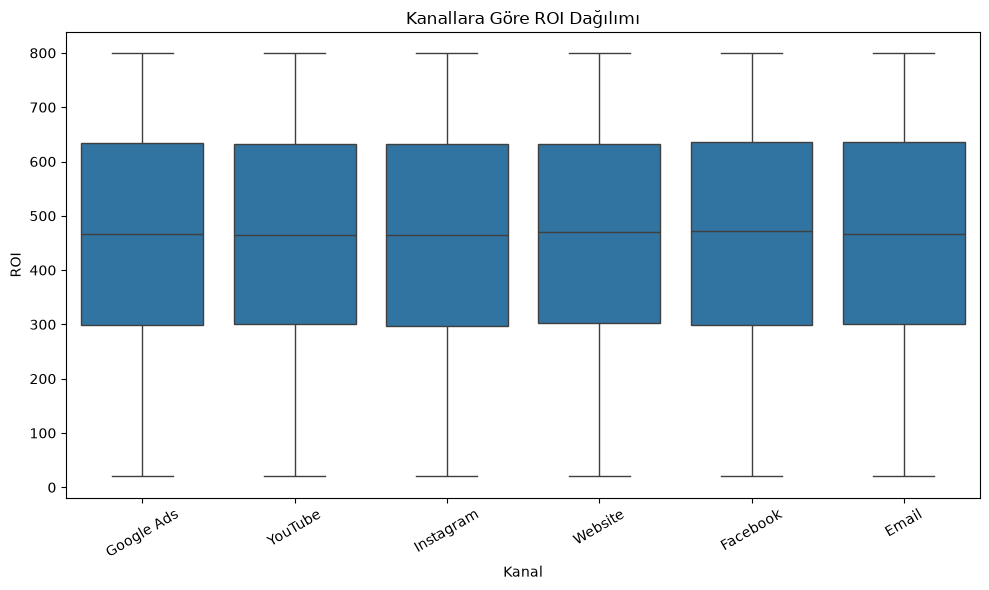

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='channel_name', y='roi')
plt.title('Kanallara Göre ROI Dağılımı')
plt.xlabel('Kanal')
plt.ylabel('ROI')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('roi_kanal_boxplot.png', dpi=150)
plt.show()

In [11]:
df.to_csv('temiz_kampanya_verisi.csv', index=False)
print("Kaydedildi!")

Kaydedildi!


In [1]:
import os
print(os.getcwd())

C:\Users\Cemrenur Güzelcik


In [6]:
df['ay'] = pd.to_datetime(df['campaign_date']).dt.month
gruplar = [grup['roi'].values for isim, grup in df.groupby('ay')]
f_ist, p_deg = stats.f_oneway(*gruplar)
print(f"F={f_ist:.4f}, p={p_deg:.4f}")

F=1.1484, p=0.3180


In [ ]:
#Beklediğimiz gibi çıktı: p=0.3180, yine 0.05 eşiğinin çok üzerinde. Yani aylar arasında da ROI açısından istatistiksel olarak anlamlı bir fark yok